# Customer Segmentation Analysis


## What is Customer Segmentation?

Customer segmentation is the process of dividing a customer base into groups that share similar characteristics. Instead of treating all customers equally, segmentation enables organizations to understand how different customer groups behave and allows businesses to design targeted marketing and retention strategies.

In this project, customers are segmented based on:

- Geography
- Age
- Credit Score
- Tenure
- Account Balance

Each segment is analyzed to determine its customer churn rate.

## Notebook Structure

This notebook is organized into the following analytical sections:

1. Customer Churn by Geography
2. Customer Churn by Gender
3. Customer Churn by Age Group
4. Customer Churn by Credit Score
5. Customer Churn by Tenure Group
6. Customer Churn by Account Balance
7. High-Value Customer Churn Analysis and Risk Analysis
8. Correlation Analysis
9. Executive Summary
10. Strategic Business Recommendations

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv('../data/cleaned_bank_churn.csv')

# 1. Customer Churn by Geography

## Business Question

Does customer churn vary across different European countries, and which geographic market represents the highest retention risk?

## Methodology

Customers are grouped according to their geographic location (France, Germany, and Spain). The churn rate for each country is calculated as the percentage of customers whose **Exited** value equals **1**. This comparison helps identify regional differences in customer retention and highlights markets requiring targeted business intervention.



In [2]:
geo_segment = (
    df.groupby("Geography")
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100),
          Avg_Balance=("Balance", "mean"),
          Avg_Credit=("CreditScore", "mean")
      )
      .round(2)
)

geo_segment

,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Credit
Geography,,,,,
France,5014,810,16.15,62092.64,649.67
Germany,2509,814,32.44,119730.12,651.45
Spain,2477,413,16.67,61818.15,651.33


## Findings

 Germany records the highest customer churn rate among the three countries, indicating significantly greater customer attrition compared with France and Spain.

## Business Implication

Geographic differences in churn suggest that customer behavior varies across regional markets. Retention strategies should therefore be customized for each country rather than applying a single organization-wide approach.

# 2. Customer Churn by Gender

## Business Question

Does customer churn differ between male and female customers?

## Methodology

Customers are segmented according to gender, and the churn rate is calculated for each group. This analysis evaluates whether gender-related differences exist in customer retention behavior.


In [14]:
gender_segment = (
    df.groupby("Gender", observed=False)
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100),
          Avg_Balance=("Balance", "mean"),
          Avg_Salary=("EstimatedSalary", "mean")
      )
      .round(2)
)

gender_segment

,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary
Gender,,,,,
Female,4543,1139,25.07,75659.37,100601.54
Male,5457,898,16.46,77173.97,99664.58


## Findings

Female customers exhibit a higher churn rate than male customers, indicating a greater likelihood of customer attrition within this demographic.

## Business Implication

Understanding gender-based differences enables the bank to investigate whether customer experience, product preferences, or service quality vary across demographic groups and supports the development of targeted retention initiatives

# 3. Customer Churn by Age Group

## Business Question

Which customer age group demonstrates the highest likelihood of churn?

## Methodology

Customers are categorized into predefined business age groups:

- Below 30 years
- 30–45 years
- 46–60 years
- Above 60 years

The churn rate is calculated for each segment to identify age-related retention patterns.


In [ ]:
age_segment = (
    df.groupby("Age", observed=False)
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100),
          Avg_Balance=("Balance", "mean"),
          Avg_Salary=("EstimatedSalary", "mean")
      )
      .round(2)
)

age_segment

,Customers,Churned,Churn_Rate,Avg_Balance,Avg_Salary
Age,,,,,
18,22,2,9.09,79169.58,85102.39
19,27,1,3.70,70502.54,97734.10
20,40,2,5.00,76038.89,97705.54
21,53,3,5.66,75926.88,102536.67
22,84,12,14.29,68213.75,98321.62
...,...,...,...,...,...
83,1,0,0.00,123356.63,92934.41
84,2,1,50.00,90057.86,187360.25
85,1,0,0.00,0.00,116537.96


## Findings

Customers aged between 46 and 60 years exhibit the highest churn rate, whereas younger customers demonstrate comparatively stronger retention.

## Business Implication

Age-specific retention strategies should prioritize middle-aged customers, as reducing churn within this segment has the potential to significantly improve overall customer retention.

# 4. Customer Churn by Credit Score

## Business Question

Does customer creditworthiness influence churn?

## Methodology

Customers are classified into three credit score categories:

- Low
- Medium
- High

The churn rate is calculated for each segment to determine whether creditworthiness is associated with customer attrition.


In [19]:
bins = [0, 579, 739, 850]
labels = ["Low", "Medium", "High"]
df["Credit_Band"] = pd.cut(df["CreditScore"], bins=bins, labels=labels)

credit_segment = (
    df.groupby("CreditScore", observed=False)
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100),
          Avg_Balance=("Balance", "mean")
      )
      .round(2)
)

credit_segment

,Customers,Churned,Churn_Rate,Avg_Balance
CreditScore,,,,
350,5,5,100.00,74701.91
351,1,1,100.00,163146.46
358,1,1,100.00,143542.36
359,1,1,100.00,128747.69
363,1,1,100.00,146098.43
...,...,...,...,...
846,5,2,40.00,53898.52
847,6,2,33.33,91220.92
848,5,0,0.00,118060.54



## Findings

Customers with lower credit scores exhibit slightly higher churn rates than customers with medium or high credit scores; however, the differences remain relatively small.

## Business Implication

Credit score alone does not appear to be a strong predictor of customer churn. It should therefore be considered alongside demographic and behavioral characteristics during customer retention planning.

# 5. Customer Churn by Tenure Group

## Business Question

Does the length of a customer's relationship with the bank influence their likelihood of churning?

## Methodology

Customers are segmented into three tenure groups based on the number of years they have maintained a relationship with the bank:

- **New Customers:** 0–3 years
- **Mid-Term Customers:** 4–7 years
- **Long-Term Customers:** 8–10 years

The customer churn rate is calculated for each tenure group to evaluate whether customer loyalty, measured by relationship duration, is associated with customer retention.



In [5]:
def tenure_group(years):
    if years <= 3:
        return "New"

    elif years <= 7:
        return "Mid-Term"

    else:
        return "Long-Term"

df["Tenure_Group"] = df["Tenure"].apply(tenure_group)

In [6]:
tenure_segment = (
    df.groupby("Tenure")
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100)
      )
      .round(2)
)

tenure_segment

,Customers,Churned,Churn_Rate
Tenure,,,
0,413,95,23.00
1,1035,232,22.42
2,1048,201,19.18
3,1009,213,21.11
4,989,203,20.53
5,1012,209,20.65
6,967,196,20.27
7,1028,177,17.22
8,1025,197,19.22


## Findings

Long-term customers demonstrate the lowest churn rate, suggesting that customers who maintain a longer relationship with the bank are generally more loyal. Conversely, newer customers exhibit comparatively higher churn, indicating that the initial years of the customer lifecycle are critical for retention.
*

## Business Implication

Customer retention efforts should place greater emphasis on customers during the early stages of their relationship with the bank. Effective onboarding, personalized engagement, and proactive support during the first few years may improve long-term customer loyalty and reduce overall churn.

# 6. Customer Churn by Account Balance

## Business Question

Does customer account balance influence churn behavior?

## Methodology

Customers are segmented into three business-defined balance categories:

- Zero Balance
- Low Balance
- High Balance

Churn rates are calculated for each segment to evaluate whether customer financial position influences retention.


In [7]:
balance_segment = (
    df.groupby("Balance")
      .agg(
          Customers=("Exited", "count"),
          Churned=("Exited", "sum"),
          Churn_Rate=("Exited", lambda x: x.mean() * 100),
          Avg_Credit=("CreditScore", "mean")
      )
      .round(2)
)

balance_segment

,Customers,Churned,Churn_Rate,Avg_Credit
Balance,,,,
0.00,3617,500,13.82,649.45
3768.69,1,1,100.00,753.00
12459.19,1,1,100.00,644.00
14262.80,1,0,0.00,702.00
16893.59,1,0,0.00,707.00
...,...,...,...,...
216109.88,1,1,100.00,663.00
221532.80,1,0,0.00,489.00
222267.63,1,1,100.00,749.00


## Findings

Customers with higher account balances demonstrate different churn behavior compared with customers holding little or no balance, suggesting that financial profile contributes to customer retention patterns.

## Business Implication

Understanding balance-related churn enables the bank to prioritize customer retention strategies according to customer financial value and potential revenue risk.

---

The preceding analyses examined churn across individual customer segments. The following section focuses specifically on premium customers to evaluate whether high-value relationships present elevated financial risk to the bank.

# 7. High-Value Customer Churn Analysis

## Business Question

Are high-value (premium) customers at significant risk of churn, and what financial impact could their attrition have on the bank?

## Methodology

Premium customers are defined as customers with an account balance of **₹100,000 or more** (or the equivalent currency value in the dataset). This segment represents customers with relatively higher financial value to the bank.

The following metrics are evaluated:

- Total number of premium customers
- Premium customer churn rate
- Average account balance
- Average estimated salary

The objective is to determine whether customer churn is concentrated among high-value customers and to quantify the potential financial exposure associated with their attrition.



In [15]:
premium = df[df["Balance"] >= 100000]

premium

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Tenure_Group
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Long-Term
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,New
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1,Long-Term
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1,Mid-Term
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0,Mid-Term
...,...,...,...,...,...,...,...,...,...,...,...,...
9985,659,France,Male,36,6,123841.49,2,1,0,96833.00,0,Mid-Term
9986,673,Germany,Male,47,1,183579.54,2,0,1,34047.54,0,New
9987,606,Spain,Male,30,8,180307.73,2,1,1,1914.41,0,Long-Term
9993,644,France,Male,28,7,155060.41,1,1,0,29179.52,0,Mid-Term


In [9]:
premium_summary = {
    "Premium Customers": len(premium),
    "Premium Churn Rate": round(premium["Exited"].mean() * 100, 2),
    "Average Balance": round(premium["Balance"].mean(), 2),
    "Average Salary": round(premium["EstimatedSalary"].mean(), 2)
}

premium_summary

{'Premium Customers': 4799,
 'Premium Churn Rate': np.float64(25.23),
 'Average Balance': np.float64(132391.09),
 'Average Salary': np.float64(100710.9)}

## Findings

The premium customer segment represents a significant proportion of the bank's total deposits. Although premium customers constitute a smaller share of the customer base, their churn rate remains substantial, indicating that customer attrition within this segment poses a considerable financial risk.

The analysis further shows that premium customers maintain significantly higher account balances than the overall customer population, increasing the potential revenue loss when these customers leave the bank.

## Business Implication

Retaining high-value customers should be a strategic priority. Personalized relationship management, premium banking services, loyalty programs, and proactive customer engagement initiatives should be implemented to reduce churn within this segment and protect long-term revenue.

In [17]:
revenue_risk = premium.loc[premium["Exited"] == 1, "Balance"].sum()

revenue_risk

np.float64(159489691.0)

## Revenue Risk Assessment

Customer churn among premium customers represents a direct financial risk due to the large balances maintained within this segment. The total balance associated with churned premium customers provides an estimate of the deposits at risk and highlights the importance of targeted retention strategies for high-value clients.

## Business Implication

Reducing churn among premium customers can generate a disproportionately positive financial impact compared with retaining lower-value customers. Consequently, premium customer retention should remain a key performance indicator within the bank's customer relationship strategy.

In [10]:
churned = df[df["Exited"] == 1]

In [11]:
print(churned["Geography"].mode()[0])
print(churned["Gender"].mode()[0])
print(churned["Age"].mode()[0])
print(churned["Balance"].mode()[0])
print(churned["CreditScore"].mode()[0])
print(churned["Tenure"].mode()[0])

Germany
Female
46
0.0
850
1


---

The previous sections evaluated churn from a business segmentation perspective. The following analysis examines statistical relationships among numerical variables to identify potential associations with customer churn.

# 8. Correlation Analysis

## Business Question

Which numerical customer attributes demonstrate the strongest relationship with customer churn?

## Methodology

A Pearson correlation matrix is used to examine the strength and direction of relationships among numerical variables. Correlation coefficients range between -1 and +1, where values closer to ±1 indicate stronger relationships.


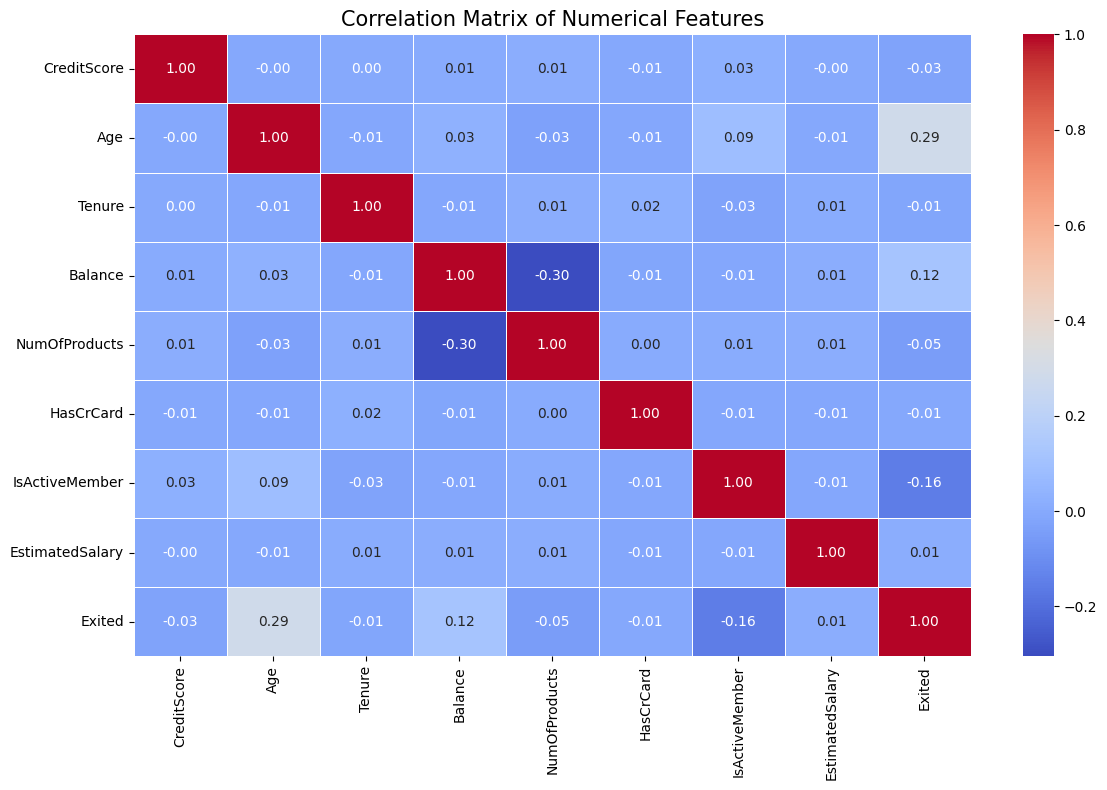

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features", fontsize=15)
plt.tight_layout()
plt.show()


## Findings

Age demonstrates the strongest positive relationship with customer churn among the numerical variables analyzed, whereas Estimated Salary and Credit Score exhibit relatively weak linear relationships. Overall, no single variable explains churn independently, indicating that customer attrition is influenced by multiple demographic, behavioral, and financial factor

## Business Implication

Customer churn is influenced by multiple demographic, behavioral, and financial characteristics rather than a single customer attribute. Consequently, customer retention strategies should adopt a multi-dimensional approach.

# 9. Executive Summary

## Project Overview

This analysis investigated customer churn patterns within a European retail banking dataset to identify customer segments exhibiting elevated churn risk. Through exploratory analysis, customer segmentation, and comparative evaluation, the study provides actionable business insights to support customer retention strategies.

## Key Findings

- Germany demonstrates the highest customer churn rate among all geographic regions.
- Female customers exhibit greater customer attrition than male customers.
- Customers aged between 46 and 60 years represent the highest-risk demographic segment.
- Inactive customers churn at substantially higher rates than active customers.
- Customer balance contributes to churn behavior, although demographic and behavioral characteristics demonstrate stronger relationships.
- Customers maintaining two banking products exhibit the strongest retention.

## Conclusion

Customer churn is driven by a combination of demographic, behavioral, and financial characteristics. The analytical findings enable banking institutions to identify high-risk customer groups, prioritize retention initiatives, and support data-driven strategic decision-making.

# 10. Strategic Business Recommendations

Based on the analytical findings, the following recommendations are proposed:

1. Prioritize customer retention initiatives within the German market, where churn risk is substantially higher.

2. Develop proactive engagement campaigns targeting inactive customers before account closure occurs.

3. Design personalized retention programs for customers aged between 46 and 60 years, the highest-risk demographic group.

4. Encourage product cross-selling among single-product customers while investigating the unusually high churn observed among customers with multiple products.

5. Monitor premium customers separately to reduce potential revenue loss resulting from high-value customer churn.

6. Establish an executive KPI dashboard for continuous monitoring of customer churn across demographic and financial segments.

7. Improve Customer Engagement: Implement personalized communication campaigns, loyalty programs, and digital engagement initiatives to encourage inactive customers to become active users of banking services.

# Final Conclusion

This customer segmentation analysis successfully identified demographic, behavioral, and financial characteristics associated with customer churn in a European retail banking environment.

The findings reveal that churn is concentrated within specific customer segments rather than being uniformly distributed across the customer base. Geographic location, customer age, activity status, and financial profile each contribute to varying levels of churn risk.

These insights provide a strong analytical foundation for executive KPI development, interactive dashboard creation, and targeted customer retention strategies. By focusing on high-risk and high-value customer segments, the bank can allocate resources more effectively, reduce customer attrition, and improve long-term profitability.